Classificatore basato su Support Vector Machine (SVM) lineari e
informazioni linguistiche non lessicali.
 Il primo classificatore dovrà essere costruito utilizzando SVM lineari,
impiegando come rappresentazione del testo esclusivamente
informazioni linguistiche non lessicali, estratte tramite il sistema
Profiling-UD. Per questo modello, è richiesto di:
  effettuare una valutazione tramite procedura di cross-validation a 5
fold sul training set;
  valutare le prestazioni del modello sui set di validazione e di test;
  fornire un elenco delle 20 feature più rilevanti ai fini della
classificazione.


In [ ]:
import numpy as np
import json
import csv

In [ ]:
profiling_path = '/content/drive/MyDrive/LC2 progetto/linguisticProfiling/16442.csv'

In [ ]:
def carica_features(path):
    d_features = {}
    features_name = None

    with open(path, "r") as file:
        csv_reader = csv.reader(file, delimiter="\t")
        for row in csv_reader:
            if features_name is None:
                features_name = row[1:] #la prims riga ha i nomi delle features
            else:
              # nel dizionario mi interessa che ci sia il nome e il tipo di set e le features
                features = [float(el) for el in row[1:]] # salvo le features che sono dal secondo elemento
                # dataset/validation/woolf_175_validation.conllu esempiodi come sono salvati i nomi
                nome_file = row[0].split("/")[-1] #woolf_175_validation.conllu
                doc_id = nome_file.split(".")[0] #woolf_175_validation
                autore = doc_id.split("_")[0] #woolf
                tipoSet = doc_id.split("_")[-1] #tipo di set, qui sarebbe validation


                # inserisco i dati nel dizionario
                d_features[doc_id] = {'autore': autore, 'set': tipoSet}
                # aggiungo le features
                d_features[doc_id]['features'] = features

    return d_features, features_name

In [ ]:
dataset, features_name = carica_features(profiling_path)

In [ ]:
print(f'Numero features: {len(features_name)}')
print('\nLista features:')
print(features_name[:10])

Numero features: 124

Lista features:
['n_sentences', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'upos_dist_ADJ', 'upos_dist_ADP', 'upos_dist_ADV', 'upos_dist_AUX', 'upos_dist_CCONJ', 'upos_dist_DET']


In [ ]:
doc_id = 'woolf_175_validation'
print(f'Primo documento, id {doc_id}')
for key, value in dataset[doc_id].items():
    print(f'{key}: ', value)

Primo documento, id woolf_175_validation
autore:  woolf
set:  validation
features:  [7.0, 60.0, 8.571428571428571, 4.528301886792453, 1.6666666666666667, 5.0, 6.666666666666667, 10.0, 3.3333333333333335, 6.666666666666667, 1.6666666666666667, 13.333333333333334, 0.0, 1.6666666666666667, 21.666666666666668, 3.3333333333333335, 11.666666666666666, 0.0, 0.0, 13.333333333333334, 0.0, 0.4339622641509434, 57.142857142857146, 42.857142857142854, 25.0, 75.0, 50.0, 0.0, 0.0, 50.0, 100.0, 0.0, 0.0, 0.0, 40.0, 60.0, 0.0, 100.0, 66.66666666666667, 0.0, 16.666666666666668, 16.666666666666668, 75.0, 0.0, 0.0, 25.0, 1.2857142857142858, 85.71428571428571, 3.125, 0.0, 0.0, 37.5, 12.5, 50.0, 0.0, 0.0, 2.2857142857142856, 6.666666666666667, 3.5714285714285716, 2.0652173913043477, 5.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 20.0, 80.0, 100.0, 0.0, 1.6666666666666667, 1.6666666666666667, 0.0, 6.666666666666667, 1.6666666666666667, 0.0, 5.0, 3.3333333333333335, 5.0, 3.3333333333333335, 0.0, 1.6666666666666667, 3.333

Divisione training, test e validation


In [ ]:
# faccio la divisione dei tre set
# training set: usato per addestrare il modello,
# test set: usato per la valutazione finale,
# validation set: usato per controllare le
# prestazioni durante lo sviluppo.

train_features, test_features, validation_features = [], [], []
train_labels, test_labels, validation_labels = [], [], []

for doc_id in dataset:
    split = dataset[doc_id]['set']
    features = dataset[doc_id]['features']
    autore = dataset[doc_id]['autore']

    if split == "training":
        train_features.append(features)
        train_labels.append(autore)

    elif split == "test":
        test_features.append(features)
        test_labels.append(autore)

    else:
        validation_features.append(features)
        validation_labels.append(autore)


print('training:', len(train_features), len(train_labels))
print('test:', len(test_features), len(test_labels))
print('validation:', len(validation_features), len(validation_labels))

training: 3000 3000
test: 300 300
validation: 300 300


trasformiamo le liste in matrici

In [ ]:
# trasformiamo le nostre liste in matrici per usarle con scikit-learn
X_train = np.array(train_features)
y_train = np.array(train_labels)
X_test = np.array(test_features)
y_test = np.array(test_labels)
X_validation= np.array(validation_features)
y_validation = np.array(validation_labels)

normalizzazione


In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
# Prima di classificare dobbiamo normalizzre tutti i valori delle features.
# Gli scaler più utlizzati sono lo lo Standard Scaler e il Min-Max Scaler
# min max scala le f tra 0 e 1
scaler = MinMaxScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.fit_transform(X_test)
scaled_X_validation = scaler.fit_transform(X_validation)

In [ ]:
scaled_X_train

array([[0.45454545, 0.79365079, 0.10302352, ..., 0.        , 0.        ,
        0.        ],
       [0.18181818, 0.77777778, 0.26091825, ..., 0.        , 0.        ,
        0.        ],
       [0.18181818, 0.57142857, 0.21724524, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.18181818, 0.87301587, 0.28107503, ..., 0.        , 0.        ,
        0.        ],
       [0.18181818, 0.26984127, 0.15341545, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.3015873 , 0.5968645 , ..., 0.        , 0.        ,
        0.        ]])

classificazione


In [ ]:
from sklearn.svm import LinearSVC

In [ ]:
# Addestriamo un Support Vector Classfier Lineare
# crea e addestra un classificatore lineare che potrà poi essere usato per predire la classe di nuovi esempi.
svc = LinearSVC(dual=False, max_iter=10000)
svc.fit(scaled_X_train, train_labels)

LinearSVC(dual=False, max_iter=10000)


5-fold cross-validation

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.dummy import DummyClassifier

In [ ]:
splitter = KFold(n_splits=5, random_state=42, shuffle=True)
folds = list(splitter.split(X_train))

for i in range(len(folds)):
    print(len(folds[i][0]), len(folds[i][1]))

2400 600
2400 600
2400 600
2400 600
2400 600


In [ ]:
# cross-validation k-fold, scala i dati correttamente,
# addestra un LinearSVC per ogni fold, lo confronta
# con un classificatore dummy e calcola l’accuratezza
# fold per fold e complessiva.

all_y_true = []
all_y_pred = []

for i in range(len(folds)):
    train_ids = folds[i][0]
    test_ids = folds[i][1]


    fold_X_train = X_train[train_ids]
    fold_y_train = y_train[train_ids]

    fold_X_test = X_train[test_ids]
    fold_y_test = y_train[test_ids]

    # Scaliamo le features
    scaler = MinMaxScaler()
    fold_X_train = scaler.fit_transform(fold_X_train)
    fold_X_test = scaler.transform(fold_X_test)

    kfold_svc = LinearSVC(dual=False, max_iter=10000)
    kfold_svc.fit(fold_X_train, fold_y_train)
    fold_y_pred = kfold_svc.predict(fold_X_test)
    fold_accuracy = accuracy_score(fold_y_test, fold_y_pred)

    dummy_clf = DummyClassifier(strategy="most_frequent")   # dummy classifier = baseline
    dummy_clf.fit(fold_X_train, fold_y_train)
    dummy_score = dummy_clf.score(fold_X_test, fold_y_test)

    all_y_true += fold_y_test.tolist()
    all_y_pred += fold_y_pred.tolist()
    print(f"Accuracy fold {i+1}: {fold_accuracy}, baseline: {dummy_score}")
print(f"\nOverall accuracy: {accuracy_score(all_y_true, all_y_pred)}")

Accuracy fold 1: 0.6666666666666666, baseline: 0.32166666666666666
Accuracy fold 2: 0.7116666666666667, baseline: 0.315
Accuracy fold 3: 0.7083333333333334, baseline: 0.33
Accuracy fold 4: 0.66, baseline: 0.32166666666666666
Accuracy fold 5: 0.6616666666666666, baseline: 0.31333333333333335

Overall accuracy: 0.6816666666666666


valutazione

In [ ]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

In [ ]:
print(classification_report(all_y_true, all_y_pred, zero_division=0)) # , output_dict=True

              precision    recall  f1-score   support

      austen       0.70      0.72      0.71      1000
     dickens       0.67      0.69      0.68      1000
       woolf       0.67      0.64      0.65      1000

    accuracy                           0.68      3000
   macro avg       0.68      0.68      0.68      3000
weighted avg       0.68      0.68      0.68      3000



In [ ]:
confusion_matrix(all_y_true, all_y_pred)

array([[717, 130, 153],
       [143, 691, 166],
       [160, 203, 637]])

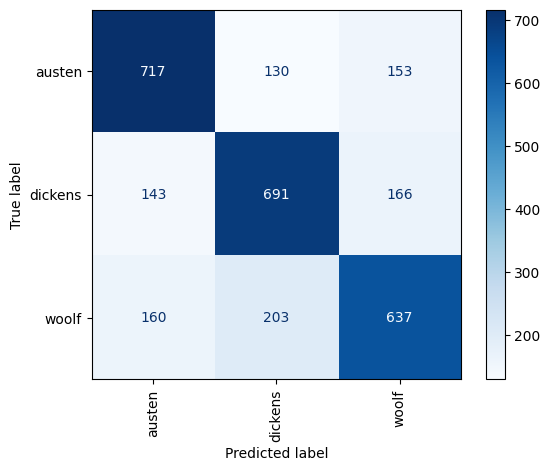

In [ ]:
ConfusionMatrixDisplay.from_predictions(all_y_true, all_y_pred, xticks_rotation='vertical', cmap='Blues');

ora su test

In [ ]:
svc = LinearSVC(dual=False, max_iter=10000)
svc.fit(scaled_X_train, train_labels)

LinearSVC(dual=False, max_iter=10000)

In [ ]:
test_predictions = svc.predict(scaled_X_test)

In [ ]:
print(classification_report(test_labels, test_predictions, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

      austen       0.48      0.80      0.60       100
     dickens       0.43      0.29      0.35       100
       woolf       0.52      0.34      0.41       100

    accuracy                           0.48       300
   macro avg       0.48      0.48      0.45       300
weighted avg       0.48      0.48      0.45       300



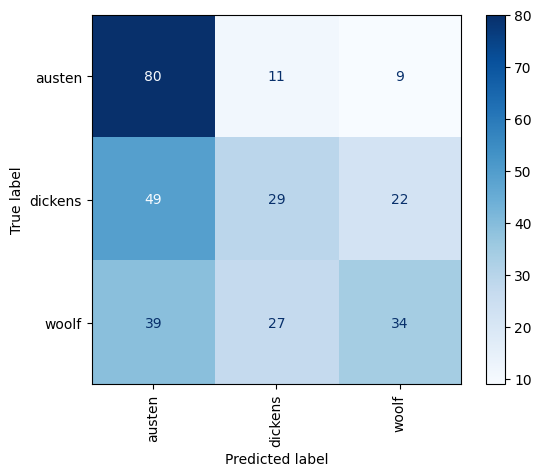

In [ ]:
ConfusionMatrixDisplay.from_predictions(test_labels, test_predictions, xticks_rotation='vertical', cmap='Blues');

e validation

In [ ]:
validation_predictions = svc.predict(scaled_X_validation)

In [ ]:
print(classification_report(validation_labels, validation_predictions, zero_division=0))#, output_dict=True))

              precision    recall  f1-score   support

      austen       0.44      0.87      0.58       100
     dickens       0.50      0.20      0.29       100
       woolf       0.53      0.33      0.41       100

    accuracy                           0.47       300
   macro avg       0.49      0.47      0.43       300
weighted avg       0.49      0.47      0.43       300



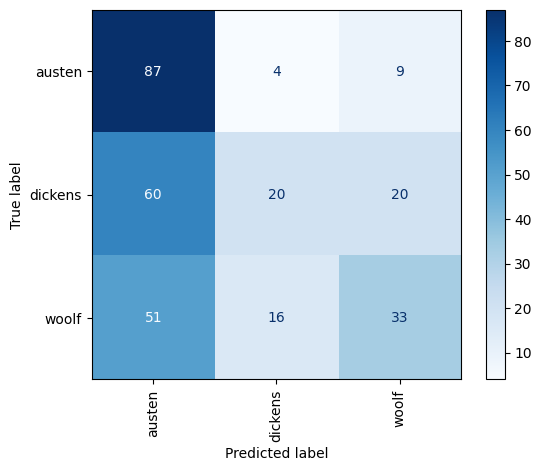

In [ ]:
ConfusionMatrixDisplay.from_predictions(validation_labels, validation_predictions, xticks_rotation='vertical', cmap='Blues');

confronto con la baseline

In [ ]:
# calcola il rapporto di classificazione per un classificatore baseline casuale, per
# confrontarlo con le prestazioni del modello reale
baseline_classifier = DummyClassifier(strategy="uniform")
baseline_classifier.fit(X_train, train_labels)
baseline_test_predictions = baseline_classifier.predict(X_test)
print(classification_report(test_labels, baseline_test_predictions, zero_division=0))

              precision    recall  f1-score   support

      austen       0.28      0.29      0.29       100
     dickens       0.31      0.30      0.30       100
       woolf       0.41      0.41      0.41       100

    accuracy                           0.33       300
   macro avg       0.33      0.33      0.33       300
weighted avg       0.33      0.33      0.33       300



le 20 features più importanti

In [ ]:
svc.classes_

array(['austen', 'dickens', 'woolf'], dtype='<U7')

In [ ]:
coefs = svc.coef_ # ndarray of shape (1, n_features) if n_classes == 2 else (n_classes, n_features)
coefs.shape

(3, 124)

Feature importance classe austen


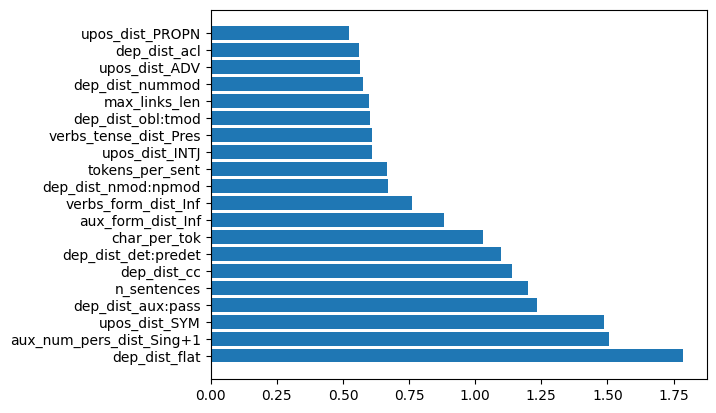

In [ ]:
import matplotlib.pyplot as plt
idx = 0
class_coefs = coefs[idx]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_name, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

num_to_plot = 20
print(f'Feature importance classe {svc.classes_[idx]}')
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align='center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.show()

Feature importance classe dickens


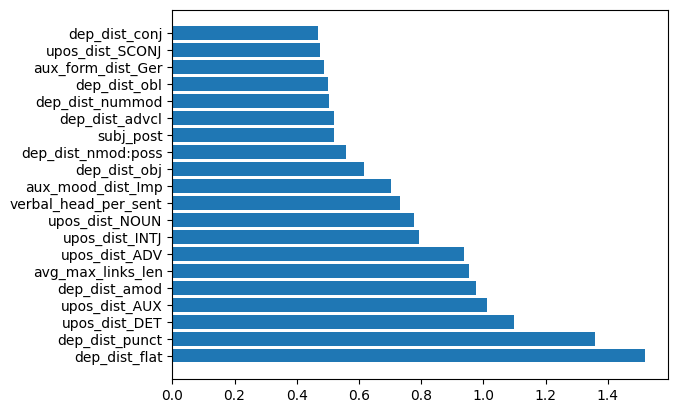

In [ ]:
idx = 1
class_coefs = coefs[idx]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_name, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))


num_to_plot = 20
print(f'Feature importance classe {svc.classes_[idx]}')
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align='center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.show()

Feature importance classe woolf


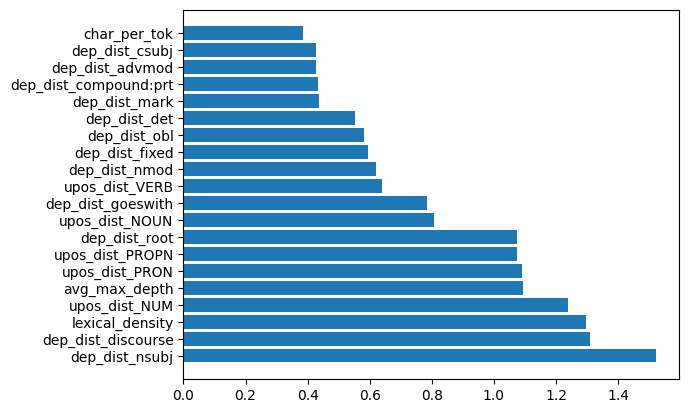

In [ ]:
idx = 2
class_coefs = coefs[idx]

feature_importances = {feature_name: coef for feature_name, coef in zip(features_name, class_coefs)}
sorted_feature_importances = dict(sorted(feature_importances.items(), key=lambda item: item[1], reverse=True))

num_to_plot = 20
print(f'Feature importance classe {svc.classes_[idx]}')
plt.barh(range(num_to_plot), list(sorted_feature_importances.values())[:num_to_plot], align='center')
plt.yticks(range(num_to_plot), list(sorted_feature_importances.keys())[:num_to_plot])
plt.show()